In [1]:
import numpy as np 
import pandas as pd 

In [2]:
#import kagglehub

#path = kagglehub.dataset_download("oddrationale/mnist-in-csv")

test_data = pd.read_csv("/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv")
train_data = pd.read_csv("/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv")

In [3]:
train_data.shape

(60000, 785)

In [4]:
test_data.shape

(10000, 785)

In [5]:
train_data.head(10) #already shuffled

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
#splitting validation and train set

val_data = train_data[:10000]
Y_val = val_data[['label']]
X_val = val_data.drop('label', axis =1)
X_val_norm = X_val/255.0

train_data = train_data[10000:]
Y_train = train_data[['label']]
X_train = train_data.drop('label', axis = 1)
X_train_norm = X_train/255.0

In [13]:
n,m = X_train_norm.shape

784

In [8]:
# --- 1. CONVERSIONE IN NUMPY ---
# Trasformiamo i DataFrame in array NumPy
X_train_np = X_train_norm.to_numpy()
# Per le Y usiamo flatten() per trasformarle da matrice colonna (N, 1) a vettore 1D (N,)
Y_train_np = Y_train.to_numpy().flatten() 

X_val_np = X_val_norm.to_numpy()
Y_val_np = Y_val.to_numpy().flatten()

# --- 2. TRASPOSIZIONE (Allineamento per Z = W*X + b) ---
# Trasponiamo le X. Ora la shape sarà (784, 50000) invece di (50000, 784)
X_train_np = X_train_np.T 
X_val_np = X_val_np.T

# --- 3. ONE-HOT ENCODING ---
def one_hot(Y, num_classes=10):
    # Crea una matrice di zeri di dimensione (numero_di_esempi, numero_di_classi)
    one_hot_Y = np.zeros((Y.size, num_classes))
    # Inserisce il valore '1' in corrispondenza dell'indice corretto
    one_hot_Y[np.arange(Y.size), Y] = 1
    # Trasponiamo per avere (10, N), allineandoci alla trasposizione fatta per la X
    return one_hot_Y.T

# Applichiamo l'encoding
Y_train_encoded = one_hot(Y_train_np)
Y_val_encoded = one_hot(Y_val_np)

print("Shape X_train:", X_train_np.shape) 
print("Shape Y_train_encoded:", Y_train_encoded.shape) 

Shape X_train: (784, 50000)
Shape Y_train_encoded: (10, 50000)


In [18]:
def init_parameters():
    W1 = np.random.rand(64,784) - 0.5
    b1 = np.zeros((64,1))
    W2 = np.random.rand(32,64) - 0.5
    b2 = np.zeros((32,1))
    W3 = np.random.rand(10,32) - 0.5
    b3 = np.zeros((10,1))
    return W1,b1,W2,b2,W3,b3

def ReLU(Z):
    return np.maximum(Z,0)

def Softmax(Z):
    shift_Z = Z - np.max(Z, axis=0, keepdims=True)
    return np.exp(shift_Z) / np.sum(np.exp(shift_Z), axis=0, keepdims=True)

def forward_propagation(X,W1,b1,W2,b2,W3,b3):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = ReLU(Z2)
    Z3 = W3.dot(A2) + b3
    A3 = Softmax(Z3)
    return Z1,A1,Z2,A2,Z3,A3

def compute_loss(one_hot_Y_pred,one_hot_Y_real):
    n = one_hot_Y_real.shape[1]
    one_hot_Y_pred_clip = np.clip(one_hot_Y_pred, 1e-15, 1 - 1e-15)
    return -(1/n)* np.sum(one_hot_Y_real * np.log(one_hot_Y_pred_clip))

def derivative_ReLU(Z):
    return Z > 0

def backpropagation(X,Z2,Z1,A3,A2,A1,W3,W2,one_hot_Y_real):
    n = one_hot_Y_real.shape[1]
    dZ3 = A3 - one_hot_Y_real
    dW3 = 1/n * (dZ3.dot(A2.T))
    db3 = 1/n * np.sum(dZ3, axis = 1,keepdims=True)
    dA2 = (W3.T).dot(dZ3)
    dZ2 = np.multiply(dA2,derivative_ReLU(Z2))
    dW2 = 1/n * (dZ2.dot(A1.T))
    db2 = 1/n * np.sum(dZ2, axis = 1,keepdims=True)
    dA1 = (W2.T).dot(dZ2)
    dZ1 = np.multiply(dA1,derivative_ReLU(Z1))
    dW1 = 1/n * (dZ1.dot(X.T))
    db1 = 1/n * np.sum(dZ1, axis = 1,keepdims=True)
    return dW3,db3,dW2,db2,dW1,db1

def update_parameters(alpha,W1,W2,W3,dW1,dW2,dW3,b1,b2,b3,db1,db2,db3):
    W1 = W1 - (alpha * dW1)
    W2 = W2 - (alpha * dW2)
    W3 = W3 - (alpha * dW3)
    b1 = b1 - (alpha * db1)
    b2 = b2 - (alpha * db2)
    b3 = b3 - (alpha * db3)
    return W1,W2,W3,b1,b2,b3

def get_predictions(A3):
    return np.argmax(A3,0)

def get_accuracy(Y_pred,Y_real):
    return np.sum(Y_pred == Y_real)/ Y_real.size

def gradient_descent(X,Y_real_flat,Y_encoded,n_iterations,alpha):
    W1,b1,W2,b2,W3,b3 = init_parameters()
    for i in range(n_iterations+1):
        Z1,A1,Z2,A2,Z3,A3 = forward_propagation(X,W1,b1,W2,b2,W3,b3)
        loss = compute_loss(A3,Y_encoded)
        dW3, db3, dW2, db2, dW1, db1 = backpropagation(X, Z2, Z1, A3, A2, A1, W3, W2, Y_encoded)
        W1,W2,W3,b1,b2,b3 = update_parameters(alpha,W1,W2,W3,dW1,dW2,dW3,b1,b2,b3,db1,db2,db3)
        if i % 50 == 0:
            acc = get_accuracy(get_predictions(A3), Y_real_flat)
            print(f"Epoca {i} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")
    return W1,W2,W3,b1,b2,b3

In [22]:
W1,W2,W3,b1,b2,b3 = gradient_descent(X_train_np,Y_train_np,Y_train_encoded,500,0.1)

Epoca 0 | Loss: 8.0239 | Accuracy: 0.0858
Epoca 50 | Loss: 0.8672 | Accuracy: 0.7203
Epoca 100 | Loss: 0.6407 | Accuracy: 0.8003
Epoca 150 | Loss: 0.5422 | Accuracy: 0.8336
Epoca 200 | Loss: 0.4830 | Accuracy: 0.8542
Epoca 250 | Loss: 0.4422 | Accuracy: 0.8664
Epoca 300 | Loss: 0.4117 | Accuracy: 0.8754
Epoca 350 | Loss: 0.3877 | Accuracy: 0.8833
Epoca 400 | Loss: 0.3680 | Accuracy: 0.8895
Epoca 450 | Loss: 0.3514 | Accuracy: 0.8948
Epoca 500 | Loss: 0.3372 | Accuracy: 0.8991


In [23]:
print("Evaluation on Validation Set...")

# 1. Forward pass usando i pesi appena addestrati
_, _, _, _, _, A3_val = forward_propagation(X_val_np, W1, b1, W2, b2, W3, b3)

# 2. Otteniamo le predizioni (gli indici del valore massimo)
val_predictions = get_predictions(A3_val)

# 3. Calcoliamo l'accuratezza confrontandole con le etichette reali
val_accuracy = get_accuracy(val_predictions, Y_val_np)

print(f"Accuracy Validation Set: {val_accuracy * 100:.2f}%")

Valutazione sul Validation Set...
Accuratezza Validation Set: 89.67%


In [24]:
print("Evaluation on Test Set...")

# 1. Separazione delle etichette (Y) dalle feature (X)
Y_test = test_data[['label']]
X_test = test_data.drop('label', axis=1)

# 2. Normalizzazione, conversione in array e trasposizione (come per il training)
X_test_np = (X_test / 255.0).to_numpy().T
Y_test_np = Y_test.to_numpy().flatten()

# 3. Singolo Forward Pass usando i pesi che hai addestrato
_, _, _, _, _, A3_test = forward_propagation(X_test_np, W1, b1, W2, b2, W3, b3)

# 4. Calcolo delle predizioni e dell'accuratezza finale
test_predictions = get_predictions(A3_test)
test_accuracy = get_accuracy(test_predictions, Y_test_np)

print(f"Accuracy Test Set: {test_accuracy * 100:.2f}%")

Evaluation on Test Set...
Accuracy Test Set: 90.18%


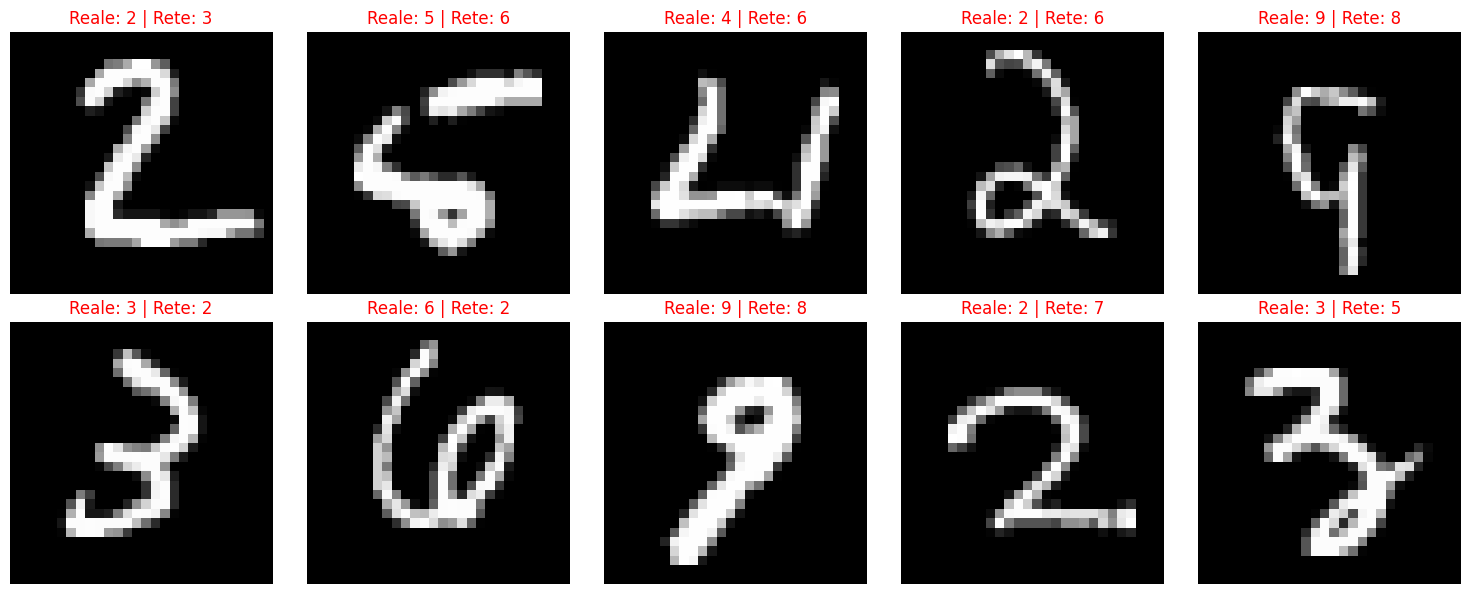

In [25]:
import matplotlib.pyplot as plt

# 1. Troviamo gli indici di tutte le predizioni sbagliate
error_indices = np.where(test_predictions != Y_test_np)[0]

# Prepariamo una figura per visualizzare 10 immagini (2 righe da 5)
plt.figure(figsize=(15, 6))

for i in range(10):
    # Prendiamo l'indice dell'errore i-esimo
    idx = error_indices[i]
    
    # Estraiamo i 784 pixel dell'immagine
    # Nota: X_test_np ha le immagini sulle colonne, quindi usiamo [:, idx]
    image_flat = X_test_np[:, idx]
    
    # Riportiamo l'array 1D alla forma di immagine 2D (28x28 pixel)
    image_2d = image_flat.reshape(28, 28)
    
    # Recuperiamo l'etichetta reale e quella predetta
    true_label = Y_test_np[idx]
    pred_label = test_predictions[idx]
    
    # Disegniamo l'immagine
    plt.subplot(2, 5, i + 1)
    plt.imshow(image_2d, cmap='gray')
    
    # Aggiungiamo un titolo con il confronto (in rosso per indicare l'errore)
    plt.title(f"Reale: {true_label} | Rete: {pred_label}", color='red')
    plt.axis('off') # Nascondiamo gli assi cartesiani

plt.tight_layout()
plt.show()